In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy

torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'high_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

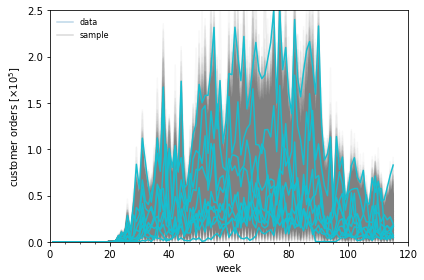

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs['high_service'])

In [10]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0, requires_grad=True)


In [11]:
class SequentialController(torch.nn.Module):
    def __init__(self, lr, le):
        super().__init__()
        #TODO: query si decoder sequence, i.e. future qs
        #key is past position or value, i.e. positional embedding
        #value is compressed state.        
        # cutoff point is required.
        
        self.layer_norm_1 = torch.nn.LayerNorm([T,1])
        self.initial_guess_nn = torch.nn.Linear(1, 38)
        
        
        self.layer_norm_2 = torch.nn.LayerNorm([T, 2])
        self.sequential_layer = nn.Transformer(nhead=1, num_encoder_layers=1. num_decoder_layers=1)
        torch.nn.MultiheadAttention(embed_dim=2, num_heads=1, kdim=3, vdim=3, batch_first=True)
        
        self.layer_norm_3 = torch.nn.LayerNorm([T, 2])
        self.output_layer = torch.nn.Linear(2, 38)

        self.lr = lr
        self.le = le
        
        
    def calculate_qs2(self, h):          
        qr_quant = fractional_decoupling(torch.relu(h[:, :, 0]+1)*torch.exp(h[:, :, 1:18].sum(-1)))
        qr_dec = binary_decoupling(h[:, :, 18])
        
        qe_quant = fractional_decoupling(torch.relu(h[:, :, 19]+1)*torch.exp(h[:, :, 20:37].sum(-1)))
        qe_dec = binary_decoupling(h[:, :, 37])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
    
    def calculate_qs(self, h, allow_neg=False):          
        qr_quant = fractional_decoupling(h[:, :, 0] if allow_neg else torch.relu(h[:, :, 0]))
        qr_dec = binary_decoupling(h[:, :, 1])
        
        qe_quant = fractional_decoupling(h[:, :, 2] if allow_neg else torch.relu(h[:, :, 2]))
        qe_dec = binary_decoupling(h[:, :, 3])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
    
    def get_arrived_qs(self, qr, qe):
        arrived_qr = qr.roll(self.lr, dims=(1,)).unsqueeze(-1)
        arrived_qr[:, :self.lr, :] = 0*arrived_qr[:, :self.lr, :]
        
        arrived_qe = qe.roll(self.le, dims=(1,)).unsqueeze(-1)
        arrived_qe[:, :self.le, :] = 0*arrived_qe[:, :self.le, :]
        return arrived_qr, arrived_qe
        
        
    def forward(self, past_demands, I_0, use_causal_mask=False):
        state = I_0 - past_demands
        x = self.layer_norm_1(state.unsqueeze(-1))
        h =  self.initial_guess_nn(x)
        qr, qe = self.calculate_qs2(h)
                
        arrived_qr, arrived_qe = self.get_arrived_qs(qr, qe)
        
        query = torch.stack([qr, qe], -1)
        
        key = torch.cat([past_demands.unsqueeze(-1), arrived_qr, arrived_qe], -1)
        value = key
        
        attn_causal_mask = None
        if use_causal_mask:
            attn_causal_mask = torch.tril(torch.ones((T,T))).int()
            
        attn_output, attn_weights = self.sequential_layer(query, 
                                                          key, 
                                                          value, 
                                                          attn_mask=attn_causal_mask
                                                         )
        
        normed_attn = self.layer_norm_3(attn_output)
        h = self.output_layer(normed_attn)
        nqr, nqe = self.calculate_qs2(h)

                
        return torch.relu(nqr), torch.relu(nqe)

In [12]:
sc = SequentialController(sourcing_parameters['lr'], sourcing_parameters['le'])

In [13]:
best_model = [deepcopy(sc.state_dict())]
best_cost = [np.infty]

In [14]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=5e-3)
optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

In [15]:
N=16
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

In [16]:
sc.train()
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
demands = torch.cat([initial_demands, future_demands], dim=-1).float()
past_demands = demands[:, :-1]
compressed_input = (inital_inventories - past_demands).unsqueeze(-1)

for i in range(10000):
    optimizer.zero_grad()
    new_qr, new_qe = sc(past_demands, sds.I_0)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe
    
    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]
    
    
    
    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    mean_costs = costs.mean()
    J = mean_costs#((costs > costs.quantile(0.5, dim=1, keepdim=True))*costs).mean()#mean_costs #+ (1.5*costs.max(dim=0).values).mean()
    

    
    J.backward()
    optimizer.step()
    
    if mean_costs.item() < best_cost[0] and i > 200:
        best_cost[0] = mean_costs.item()
        best_model[0] = deepcopy(sc.state_dict())
    
    if i%2000 == 0 and i > 0:
        future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
        inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
        demands = torch.cat([initial_demands, future_demands], dim=-1).float()
        past_demands = demands[:, :-1]
        compressed_input = (fractional_decoupling(inital_inventories)  - past_demands).unsqueeze(-1)
        print(costs.mean())
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-5)
        optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

tensor(34447864., grad_fn=<MeanBackward0>)
tensor(3134913.5000, grad_fn=<MeanBackward0>)
tensor(1895011.3750, grad_fn=<MeanBackward0>)
tensor(1733414.6250, grad_fn=<MeanBackward0>)


In [17]:
best_cost

[986761.125]

In [18]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [19]:
N=1024
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

with torch.no_grad():
    sc.eval()
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()

    past_demands = demands[:, :-1]
    new_qr, new_qe = sc(past_demands, sds.I_0, False)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    print('Mean: ' + str(costs.mean().item()))
    print('Median: ' + str(costs.median().item()))

Mean: 23359738.0
Median: 944591.75


In [20]:
costs.mean()

tensor(23359738.)

In [21]:
(new_qe > 0).any()

tensor(True)

In [22]:
new_qr

tensor([[ 2477.,  2617.,  2770.,  ..., 33734., 10860., 10860.],
        [ 1983.,  2096.,  2220.,  ..., 27658.,  8676.,  8677.],
        [ 2264.,  2393.,  2533.,  ..., 31085.,  9909.,  9909.],
        ...,
        [ 2255.,  2383.,  2522.,  ..., 30859.,  9845.,  9845.],
        [ 2370.,  2504.,  2650.,  ..., 32416., 10384., 10384.],
        [ 1846.,  1954.,  2071.,  ..., 26474.,  8181.,  8181.]])

In [23]:
costs

tensor([[0.0000e+00, 0.0000e+00, 1.2385e+04,  ..., 8.0627e+05, 7.8207e+05,
         6.9462e+05],
        [0.0000e+00, 0.0000e+00, 9.9150e+03,  ..., 2.5321e+06, 2.5213e+06,
         2.6027e+06],
        [0.0000e+00, 0.0000e+00, 1.1320e+04,  ..., 1.2338e+08, 1.1795e+08,
         1.2603e+08],
        ...,
        [0.0000e+00, 0.0000e+00, 1.1275e+04,  ..., 3.5229e+06, 3.4848e+06,
         3.5115e+06],
        [0.0000e+00, 0.0000e+00, 1.1850e+04,  ..., 1.6271e+06, 1.6558e+06,
         1.6155e+06],
        [0.0000e+00, 0.0000e+00, 9.2300e+03,  ..., 2.1106e+08, 2.0680e+08,
         2.1136e+08]])

In [24]:
invs

tensor([[      0.0000,       0.0000,    2477.0000,  ...,  161254.7656,
          156412.9375,  138924.4375],
        [      0.0000,       0.0000,    1983.0000,  ...,  506421.0000,
          504264.0938,  520530.3750],
        [      0.0000,       0.0000,    2264.0000,  ..., -249259.0781,
         -238288.0938, -254608.8750],
        ...,
        [      0.0000,       0.0000,    2255.0000,  ...,  704579.6250,
          696964.1875,  702299.5000],
        [      0.0000,       0.0000,    2370.0000,  ...,  325428.0000,
          331151.9375,  323105.8438],
        [      0.0000,       0.0000,    1846.0000,  ..., -426379.3438,
         -417772.8438, -426996.5938]])

In [25]:
demands

tensor([[    0.0000,     0.0000,     0.0000,  ..., 29022.0820, 34807.8242,
         51222.5039],
        [    0.0000,     0.0000,     0.0000,  ..., 27039.1895, 26694.8926,
         11391.7256],
        [    0.0000,     0.0000,     0.0000,  ..., 22807.9219, 16630.0156,
         47405.7734],
        ...,
        [    0.0000,     0.0000,     0.0000,  ..., 27244.7051, 35020.4141,
         25523.6562],
        [    0.0000,     0.0000,     0.0000,  ...,  3955.4866, 23065.0742,
         40462.0820],
        [    0.0000,     0.0000,     0.0000,  ..., 40529.6016, 14849.4961,
         35697.7422]])

In [26]:
new_qe

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])